In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df_Swiggy=pd.read_csv("Swiggy Bangalore Outlet Details.csv")
df_Swiggy

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,₹ 150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,₹ 400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,₹ 126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,₹ 400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,₹ 450
...,...,...,...,...,...
113,Wok Paper Scissors,"Pan-Asian, Chinese, Asian","JNC Road, Koramangala",3.9,₹ 219
114,Savoury Restaurant,"Arabian, Middle Eastern, North Indian, Grill, ...","Madiwala, BTM",4.1,₹ 600
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,₹ 193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,₹ 200


In [3]:
# How many features values are there in datasets
df_Swiggy.columns

Index(['Shop_Name', 'Cuisine', 'Location', 'Rating', 'Cost_for_Two'], dtype='object')

In [4]:
#Check for missing values in datasets
df_Swiggy.isnull().sum()    #df_Swiggy.isna().sum(): another way to check null

,0
Shop_Name,0
Cuisine,0
Location,0
Rating,0
Cost_for_Two,0


In [5]:
df_Swiggy.isnull().sum().sum()    # to check exact number of null values

np.int64(0)

In [6]:
# Logic structure
df_Swiggy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Shop_Name     118 non-null    object
 1   Cuisine       118 non-null    object
 2   Location      118 non-null    object
 3   Rating        118 non-null    object
 4   Cost_for_Two  118 non-null    object
dtypes: object(5)
memory usage: 4.7+ KB


In [7]:
#DATA PRE-PROCESSING & CLEANING
df_Swiggy.duplicated().sum()    # to identify duplicate rows

np.int64(0)

In [8]:
# How many different ratings are in datasets
df_Swiggy['Rating'].unique()

array(['4.3', '4.4', '4.1', '4.2', '3.9', '3.8', '4', '3.7', '3.6', '4.8',
       '4.5', '4.6', '--'], dtype=object)

In [9]:
# Replacing '--' rating with zero(o) to change data type
# we choose astype to change data type from string to float
df_Swiggy['Rating']=df_Swiggy['Rating'].str.replace('--','0').astype(float)

In [10]:
# Now we check that data type is actually changed or not
df_Swiggy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Shop_Name     118 non-null    object 
 1   Cuisine       118 non-null    object 
 2   Location      118 non-null    object 
 3   Rating        118 non-null    float64
 4   Cost_for_Two  118 non-null    object 
dtypes: float64(1), object(4)
memory usage: 4.7+ KB


In [11]:
# How many unique entries for 'cost_for_Two' feature
df_Swiggy['Cost_for_Two'].unique()

array(['₹ 150', '₹ 400', '₹ 126', '₹ 450', '₹ 350', '₹ 200', '₹ 500',
       '₹ 247', '₹ 550', '₹ 300', '₹ 129', '₹ 250', '₹ 268', '₹ 600',
       '₹ 527', '₹ 130', '₹ 257', '₹ 280', '₹ 399', '₹ 220', '₹ 800',
       '₹ 100', '₹ 178', '₹ 120', '₹ 251', '₹ 650', '₹ 132', '₹ 153',
       '₹ 219', '₹ 193'], dtype=object)

In [12]:
# now removing ₹ from datasets
s1='₹ 150'
int(s1.strip('₹ ')) # to write ₹  press option + 4 this work only in mac book

150

In [13]:
# Another way to remove ₹
s1='₹ 150'
int(s1.split()[1])

150

In [14]:
df_Swiggy['Cost_for_Two']=df_Swiggy['Cost_for_Two'].apply(lambda x:int(x.strip("₹ ")))

In [15]:
# now checking the data type
df_Swiggy['Cost_for_Two'].dtype

dtype('int64')

In [16]:
df_Swiggy['Cost_for_Two'].unique()

array([150, 400, 126, 450, 350, 200, 500, 247, 550, 300, 129, 250, 268,
       600, 527, 130, 257, 280, 399, 220, 800, 100, 178, 120, 251, 650,
       132, 153, 219, 193])

In [17]:
# Handling Features ----> location
df_Swiggy['Location'].unique()

array(['Koramangala, Koramangala', 'Sector 5, HSR',
       '6th Block, Koramangala', 'HSR, HSR', '5th Block, Koramangala',
       'Koramangala 4th  Block, Koramangala', 'BTM 2nd Stage, BTM',
       'BTM, BTM', '9th Main road, Koramangala', 'outer ring road, BTM',
       '7th Block, Koramangala', '1st MAin, Koramangala',
       'Bommanahalli, BTM', '6th block, Koramangala', 'Sector 4, HSR',
       'BTM 1st stage, BTM', 'Jakkasandra Extn, Koramangala',
       'Marutinagar Main Road, BTM', '1st Block, Koramangala',
       '4th Cross, BTM', 'koramangala, Koramangala', 'BTM 2nd stage, BTM',
       '3rd main, BTM', 'HSR 1st sector, HSR', 'Sector 7, HSR',
       '3rd Sector, HSR', 'Chocolate Factory Road, BTM',
       '16th Main Road, 2nd Stage, BTM', '1st Stage, BTM',
       'Hosur Main Road, Koramangala',
       '1st Cross Road, 5th Block, Near Jyothi Nivas College, Koramangala',
       'Mico Layout, BTM', '4th Cross, Koramangala',
       '4th Block, Koramangala', 'Intermediate Ring Road, K

In [18]:
#  Location that contains "Koramangala"
Swiggy_Koramangala=df_Swiggy[df_Swiggy['Location'].str.contains("Koramangala")]
Swiggy_Koramangala

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
5,Kitchens of Punjab,North Indian,"Koramangala 4th Block, Koramangala",4.2,350
9,Yumlane Pizza,"Pizzas, Italian, Mexican","9th Main road, Koramangala",3.8,150
...,...,...,...,...,...
112,Kritunga,"Andhra, Biryani","5th Block, Koramangala",3.9,500
113,Wok Paper Scissors,"Pan-Asian, Chinese, Asian","JNC Road, Koramangala",3.9,219
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [19]:
#  Location that contains "HSR"
Swiggy_HSR=df_Swiggy[df_Swiggy['Location'].str.contains("HSR")]
Swiggy_HSR

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
8,Hotel Manu,"South Indian, Kerala, Chinese, North Indian","HSR, HSR",4.1,350
19,Shree Khana Khazana,"Indian, Rajasthani","Sector 4, HSR",4.1,350
24,New Udupi Grand,"Chinese, Jain, North Indian, South Indian","HSR, HSR",4.3,150
36,Biriyani Zone,"North Indian, Chinese, Biryani","HSR 1st sector, HSR",4.1,600
37,Gongura's,"North Indian, Chinese, Biryani","Sector 7, HSR",3.8,300
39,Leon Grill,"Turkish, Portuguese, American","3rd Sector, HSR",4.3,300
41,Cakewala,Desserts,"HSR, HSR",4.3,450
57,Donne Biriyani House,South Indian,"3rd sector, HSR",4.0,300


In [20]:
#  Location that contains "BTM"
Swiggy_BTM=df_Swiggy[df_Swiggy['Location'].str.contains("BTM")]
Swiggy_BTM

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
6,99 VARIETY DOSA AND PAV BHAJI- Malli Mane Food...,"Fast Food, North Indian, Chinese","BTM 2nd Stage, BTM",4.1,200
7,La Pino'z Pizza,Italian,"BTM, BTM",3.9,500
10,Ambur Star Briyani,"Chinese, South Indian, North Indian, Desserts,...","outer ring road, BTM",4.1,500
17,Sri Lakshmi Dhaba,North Indian,"Bommanahalli, BTM",3.7,200
20,Just Bake - Cakes & confectioners,"Desserts, Bakery","BTM 1st stage, BTM",4.3,300
22,Hotel Godavari,"North Indian, Chinese, Hyderabadi","Marutinagar Main Road, BTM",4.0,400
25,Swad Punjab da,Indian,"BTM, BTM",4.1,250
27,High N Hungry,"Andhra, Biryani, Chinese, Desserts, Fast Food,...","4th Cross, BTM",4.1,350
31,Bengali Fun Foods,North Indian,"BTM 2nd stage, BTM",4.2,300
33,Oottupura,"Kerala, South Indian","BTM, BTM",4.3,268


<Axes: xlabel='Rating', ylabel='Count'>

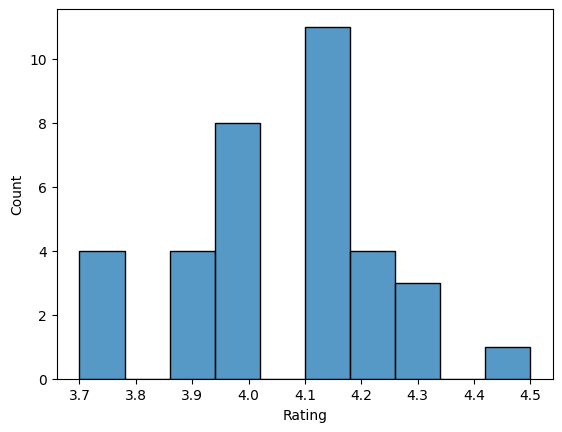

In [21]:
# BTM area
sns.histplot(Swiggy_BTM['Rating'],bins=10)

<Axes: xlabel='Rating', ylabel='Count'>

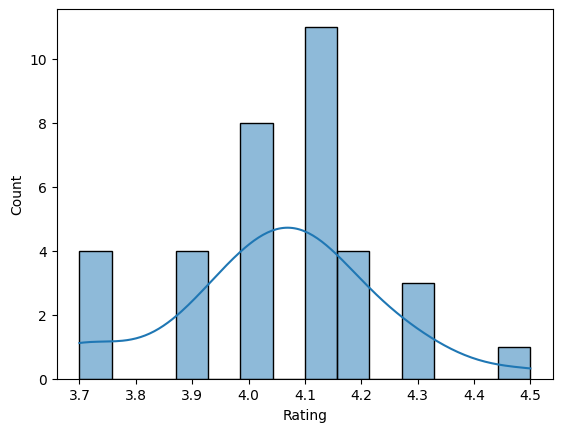

In [22]:
sns.histplot(data=Swiggy_BTM,x='Rating',kde=True)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

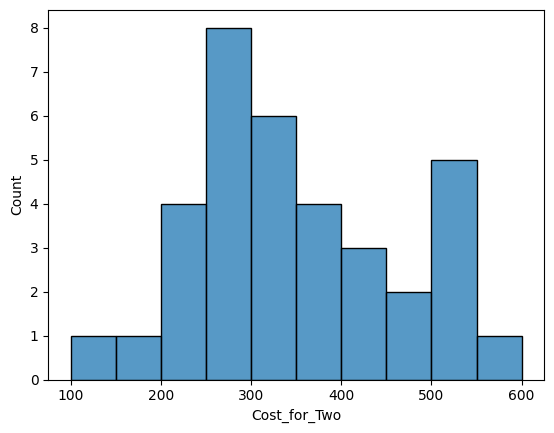

In [23]:
sns.histplot(Swiggy_BTM['Cost_for_Two'],bins=10)

In [24]:
# Conclusion :In BTM most have 4.0 to 4.2 Rating and approx .Cost_for_Two people lies between 200 to 350 .(MAX.Cost goes upto 600)

<Axes: xlabel='Rating', ylabel='Count'>

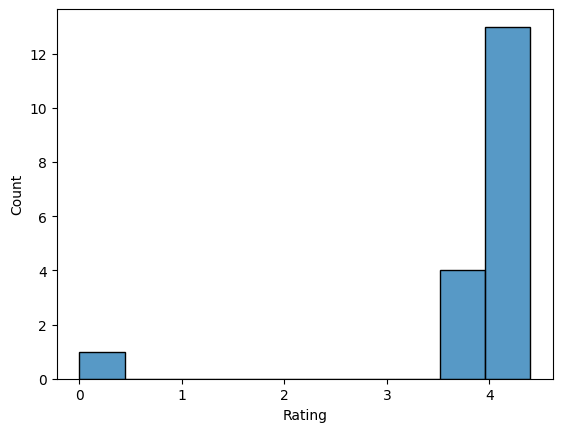

In [25]:
# HSR area
sns.histplot(Swiggy_HSR['Rating'],bins=10)

<Axes: xlabel='Rating', ylabel='Count'>

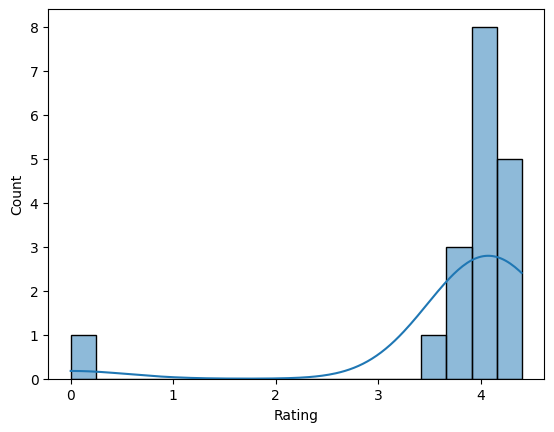

In [26]:
sns.histplot(data=Swiggy_HSR,x='Rating',kde=True)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

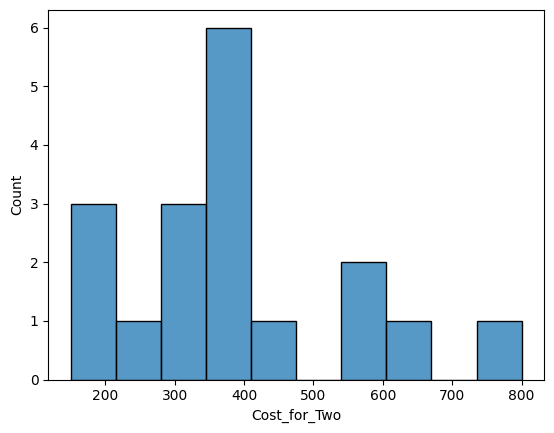

In [27]:
sns.histplot(Swiggy_HSR['Cost_for_Two'],bins=10)

In [28]:
# Conclusion :In HSR most have 4 or above Rating and approx .Cost_for_Two people lies between 300 to 400 .(MAX.Cost goes upto 800)

<Axes: xlabel='Rating', ylabel='Count'>

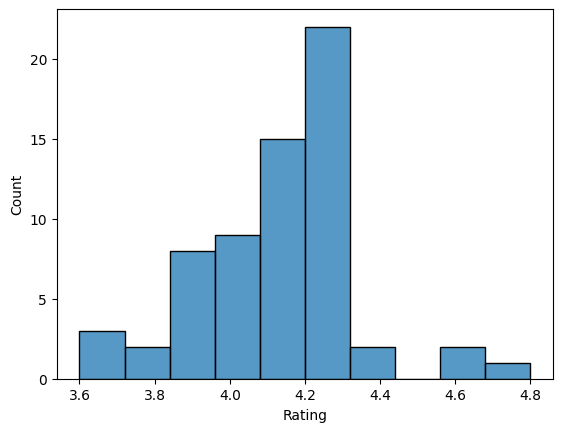

In [29]:
# Koramangala area
sns.histplot(Swiggy_Koramangala['Rating'],bins=10)

<Axes: xlabel='Rating', ylabel='Count'>

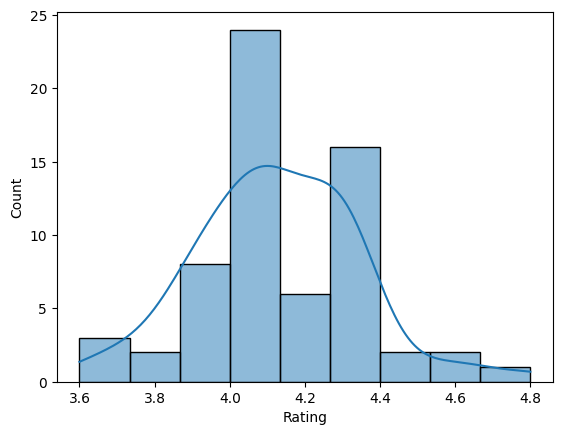

In [30]:
sns.histplot(data=Swiggy_Koramangala,x='Rating',kde=True)

<Axes: xlabel='Cost_for_Two', ylabel='Count'>

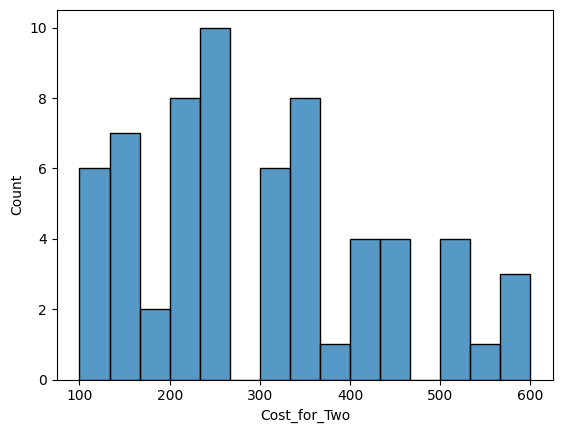

In [31]:
sns.histplot(Swiggy_Koramangala['Cost_for_Two'],bins=15)

In [32]:
# Conclusion :In Koramangala most has 4.0 to 4.3 Rating and approx .Cost_for_Two people lies between 200 to 350 .(MAX.Cost goes upto 800)

In [33]:
#For highest rated restaurants
df_Highest_Rated_Restaurants=df_Swiggy[df_Swiggy['Rating']>=4.0]
df_Highest_Rated_Restaurants

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
111,Bowl 99,"North Indian, South Indian","kormangala, Koramangala",4.4,200
114,Savoury Restaurant,"Arabian, Middle Eastern, North Indian, Grill, ...","Madiwala, BTM",4.1,600
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [34]:
# Now abstracting this Shop_Name, Rating ,Cost_for_Two columns
df_Highest_Rated_Restaurants=df_Highest_Rated_Restaurants.loc[:,['Shop_Name','Rating','Cost_for_Two']]
df_Highest_Rated_Restaurants

,Shop_Name,Rating,Cost_for_Two
0,Kanti Sweets,4.3,150
1,Mumbai Tiffin,4.4,400
2,Sri Krishna sagar,4.1,126
3,Al Daaz,4.4,400
4,Beijing Bites,4.1,450
...,...,...,...
111,Bowl 99,4.4,200
114,Savoury Restaurant,4.1,600
115,Royal Treat,4.2,193
116,Thali 99,4.3,200


In [35]:
from re import template
fig=px.scatter(
    x=df_Highest_Rated_Restaurants['Rating'],
    y=df_Highest_Rated_Restaurants['Cost_for_Two'],
    color=df_Highest_Rated_Restaurants['Rating'],
    size=df_Highest_Rated_Restaurants['Cost_for_Two'],
    labels={
        'x':'Approx.Cost_for_Two',
        'y':'Rating',
        'color':'Rating_Indicator',

    }
)
fig.update_layout(
    template='plotly_dark',
    title="Analyse'Approx Cost of 2 People'vs'Rating'"
)
fig.show()

In [36]:
#Q. Analyze Affordable/Budgeted and Highest Rated Restaurants of Bangalore :
df_Affordable_Restaurants=df_Swiggy[(df_Swiggy['Cost_for_Two']<=500 ) & (df_Swiggy['Rating']>=4.0)]
df_Affordable_Restaurants

,Shop_Name,Cuisine,Location,Rating,Cost_for_Two
0,Kanti Sweets,Sweets,"Koramangala, Koramangala",4.3,150
1,Mumbai Tiffin,"North Indian, Home Food, Thalis, Combo","Sector 5, HSR",4.4,400
2,Sri Krishna sagar,"South Indian, North Indian, Fast Food, Beverag...","6th Block, Koramangala",4.1,126
3,Al Daaz,"American, Arabian, Chinese, Desserts, Fast Foo...","HSR, HSR",4.4,400
4,Beijing Bites,"Chinese, Thai","5th Block, Koramangala",4.1,450
...,...,...,...,...,...
110,Biryani Pot,"North Indian, Biryani","Madiwala Junction, BTM",4.0,500
111,Bowl 99,"North Indian, South Indian","kormangala, Koramangala",4.4,200
115,Royal Treat,"North Indian, Chinese, Seafood, Biryani","5th block Koramangala, Koramangala",4.2,193
116,Thali 99,North Indian,"Koramangala, Koramangala",4.3,200


In [37]:
df_Affordable_Restaurants=df_Affordable_Restaurants.loc[:,['Shop_Name','Rating','Cost_for_Two']]
df_Affordable_Restaurants

,Shop_Name,Rating,Cost_for_Two
0,Kanti Sweets,4.3,150
1,Mumbai Tiffin,4.4,400
2,Sri Krishna sagar,4.1,126
3,Al Daaz,4.4,400
4,Beijing Bites,4.1,450
...,...,...,...
110,Biryani Pot,4.0,500
111,Bowl 99,4.4,200
115,Royal Treat,4.2,193
116,Thali 99,4.3,200


In [38]:
# sorting of affordable data in decending oder
df_Affordable_Restaurants=df_Affordable_Restaurants.sort_values(by='Rating',ascending=False)
df_Affordable_Restaurants

,Shop_Name,Rating,Cost_for_Two
78,Khichdi Experiment,4.8,200
82,Natural Ice Cream,4.6,150
94,Corner House Ice Cream,4.6,250
80,Chinese Bae,4.5,450
1,Mumbai Tiffin,4.4,400
...,...,...,...
96,Just Shawarma,4.0,250
105,Paradise Biryani,4.0,300
110,Biryani Pot,4.0,500
106,New Tasty Cafeteria,4.0,350


/tmp/ipykernel_10920/560520955.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




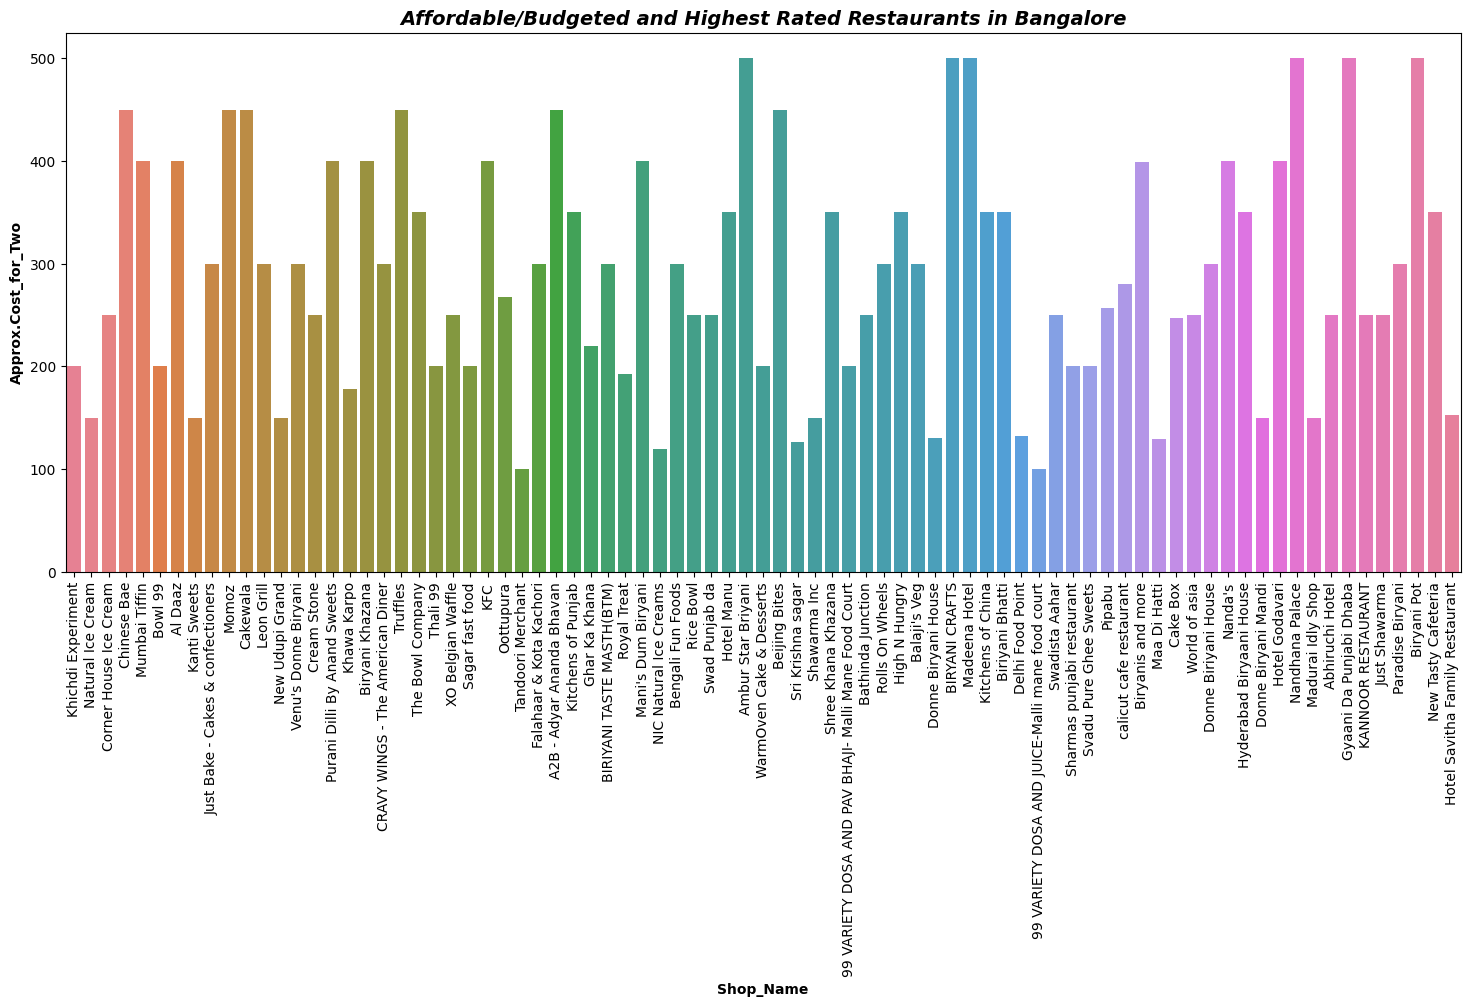

In [39]:
plt.figure(figsize=(18,7))  # 18 & 7 are the size of canva
sns.barplot(x='Shop_Name',y='Cost_for_Two',data=df_Affordable_Restaurants,palette='husl')
plt.title(
    'Affordable/Budgeted and Highest Rated Restaurants in Bangalore',
    fontsize=14,
    fontweight='bold',
    fontstyle='italic'
)
plt.xlabel('Shop_Name',fontsize=10,fontweight='bold')
plt.ylabel('Approx.Cost_for_Two',fontsize=10,fontweight='bold')
plt.xticks(rotation=90)
plt.show()

In [40]:
# Q. Top 15 cheapest & Highest Rated Restaurants with Approx. Cost for 2 People :
df_Cheapest_Restaurants=df_Affordable_Restaurants.sort_values(by='Cost_for_Two',ascending=True)
df_Cheapest_Restaurants

,Shop_Name,Rating,Cost_for_Two
79,Tandoori Merchant,4.2,100
89,99 VARIETY DOSA AND JUICE-Malli mane food court,4.1,100
95,NIC Natural Ice Creams,4.2,120
2,Sri Krishna sagar,4.1,126
21,Maa Di Hatti,4.0,129
...,...,...,...
92,BIRYANI CRAFTS,4.1,500
10,Ambur Star Briyani,4.1,500
29,Nandhana Palace,4.0,500
110,Biryani Pot,4.0,500


In [41]:
# NOW FOR TOP 15
df_Cheapest_Restaurants.head(15)

,Shop_Name,Rating,Cost_for_Two
79,Tandoori Merchant,4.2,100
89,99 VARIETY DOSA AND JUICE-Malli mane food court,4.1,100
95,NIC Natural Ice Creams,4.2,120
2,Sri Krishna sagar,4.1,126
21,Maa Di Hatti,4.0,129
53,Donne Biryani House,4.1,130
100,Delhi Food Point,4.1,132
24,New Udupi Grand,4.3,150
15,Shawarma Inc,4.1,150
0,Kanti Sweets,4.3,150


In [42]:
fig=px.bar(
    data_frame=df_Cheapest_Restaurants.head(15),
    x=df_Cheapest_Restaurants['Shop_Name'][0:15],
    y=df_Cheapest_Restaurants['Cost_for_Two'][0:15],
    color=df_Cheapest_Restaurants['Rating'][0:15],
    labels={
        'x':'Restaurant_Name',
        'y':'Approx.Cost_for_Two',
        'color':'Rating',
    }
)
fig.update_layout(
    template='plotly_dark',
    title='Top 15 Cheapest & Highest Rated Restaurants with Approx. Cost for 2 People',
)
fig.show()


In [43]:
# Q. Top 15 Expensive & Highest Rated Restaurants with Approx. Cost for 2 People :
df_Expensive_Restaurants=df_Highest_Rated_Restaurants.sort_values(by='Cost_for_Two',ascending=False)
df_Expensive_Restaurants

,Shop_Name,Rating,Cost_for_Two
73,Punjabi Rasoi,4.0,800
99,Dindigul Thalapakatti Biriyani,4.1,650
34,Taco Bell,4.3,600
46,Pizza Hut,4.0,600
36,Biriyani Zone,4.1,600
...,...,...,...
21,Maa Di Hatti,4.0,129
2,Sri Krishna sagar,4.1,126
95,NIC Natural Ice Creams,4.2,120
89,99 VARIETY DOSA AND JUICE-Malli mane food court,4.1,100


In [44]:
# NOW FOR TOP 15 Expensive
df_Cheapest_Restaurants.head(15)

,Shop_Name,Rating,Cost_for_Two
79,Tandoori Merchant,4.2,100
89,99 VARIETY DOSA AND JUICE-Malli mane food court,4.1,100
95,NIC Natural Ice Creams,4.2,120
2,Sri Krishna sagar,4.1,126
21,Maa Di Hatti,4.0,129
53,Donne Biryani House,4.1,130
100,Delhi Food Point,4.1,132
24,New Udupi Grand,4.3,150
15,Shawarma Inc,4.1,150
0,Kanti Sweets,4.3,150


In [45]:
fig=px.bar(
    data_frame=df_Expensive_Restaurants.head(15),
    x=df_Expensive_Restaurants['Shop_Name'][0:15],
    y=df_Expensive_Restaurants['Cost_for_Two'][0:15],
    color=df_Expensive_Restaurants['Rating'][0:15],
    labels={
        'x':'Restaurant_Name',
        'y':'Approx.Cost_for_Two',
        'color':'Rating',
    }
)
fig.update_layout(
    template='plotly_dark',
    title='Top 15 Expensive & Highest Rated Restaurants with Approx. Cost for 2 People',
)
fig.show()


**Cuisine Analysis**

In [46]:
df_Swiggy['Cuisine']=df_Swiggy['Cuisine'].str.title()
df_Swiggy['Cuisine']

,Cuisine
0,Sweets
1,"North Indian, Home Food, Thalis, Combo"
2,"South Indian, North Indian, Fast Food, Beverag..."
3,"American, Arabian, Chinese, Desserts, Fast Foo..."
4,"Chinese, Thai"
...,...
113,"Pan-Asian, Chinese, Asian"
114,"Arabian, Middle Eastern, North Indian, Grill, ..."
115,"North Indian, Chinese, Seafood, Biryani"
116,North Indian


In [47]:
df_Swiggy['Cuisine'].unique()

array(['Sweets', 'North Indian, Home Food, Thalis, Combo',
       'South Indian, North Indian, Fast Food, Beverages, Jain',
       'American, Arabian, Chinese, Desserts, Fast Food, Mughlai, North Indian',
       'Chinese, Thai', 'North Indian',
       'Fast Food, North Indian, Chinese', 'Italian',
       'South Indian, Kerala, Chinese, North Indian',
       'Pizzas, Italian, Mexican',
       'Chinese, South Indian, North Indian, Desserts, Fast Food, Kerala, Andhra, Beverages, Mughlai, Seafood',
       'Desserts', 'Chinese, Andhra, Biryani, Seafood', 'Chinese',
       'South Indian, Chinese, Desserts, North Indian',
       'Arabian, Fast Food', 'Desserts, Beverages', 'Indian, Rajasthani',
       'Desserts, Bakery', 'Chinese, Healthy Food, North Indian',
       'North Indian, Chinese, Hyderabadi', 'Fast Food',
       'Chinese, Jain, North Indian, South Indian', 'Indian',
       'North Indian, South Indian, Chinese',
       'Andhra, Biryani, Chinese, Desserts, Fast Food, Seafood, South In

In [48]:
df_Swiggy['Cuisine'].str.split(', ')

,Cuisine
0,[Sweets]
1,"[North Indian, Home Food, Thalis, Combo]"
2,"[South Indian, North Indian, Fast Food, Bevera..."
3,"[American, Arabian, Chinese, Desserts, Fast Fo..."
4,"[Chinese, Thai]"
...,...
113,"[Pan-Asian, Chinese, Asian]"
114,"[Arabian, Middle Eastern, North Indian, Grill,..."
115,"[North Indian, Chinese, Seafood, Biryani]"
116,[North Indian]


In [49]:
freq_dict={}
for i in df_Swiggy['Cuisine'].unique():
  cuisines_Lists=i.split(', ')        # words list
  for Cuisine in cuisines_Lists:
    Cuisine=Cuisine.lstrip(' ')  #remove left space
    if Cuisine in freq_dict:
      freq_dict[Cuisine]=freq_dict[Cuisine]+1
    else:
      freq_dict[Cuisine]=1
print(freq_dict)
print()
print('Total Record :',len(freq_dict))


{'Sweets': 2, 'North Indian': 32, 'Home Food': 2, 'Thalis': 1, 'Combo': 1, 'South Indian': 23, 'Fast Food': 16, 'Beverages': 9, 'Jain': 2, 'American': 8, 'Arabian': 4, 'Chinese': 35, 'Desserts': 15, 'Mughlai': 7, 'Thai': 2, 'Italian': 4, 'Kerala': 6, 'Pizzas': 5, 'Mexican': 3, 'Andhra': 12, 'Seafood': 8, 'Biryani': 18, 'Indian': 5, 'Rajasthani': 1, 'Bakery': 2, 'Healthy Food': 4, 'Hyderabadi': 5, 'Snacks': 4, 'Turkish': 2, 'Portuguese': 2, 'Chaat': 2, 'Asian': 3, 'Continental': 3, 'Mediterranean': 1, 'Lebanese': 1, 'Cafe': 2, 'Salads': 2, 'Pastas': 1, 'Punjabi': 2, 'Juices': 2, 'Kebabs': 2, 'Grill': 2, 'Ice Cream': 2, 'Tandoor': 1, 'Chettinad': 2, 'Pan-Asian': 2, 'Oriental': 1, 'Middle Eastern': 1}

Total Record : 48


In [50]:
# Extracting Cuisine name and there frequency
Cuisine= freq_dict.keys()
freq=freq_dict.values()


df_Cuisine_Analysis=pd.DataFrame({
    'Cuisine':Cuisine,
    'Count':freq
}) # Empty data frame
df_Cuisine_Analysis

,Cuisine,Count
0,Sweets,2
1,North Indian,32
2,Home Food,2
3,Thalis,1
4,Combo,1
5,South Indian,23
6,Fast Food,16
7,Beverages,9
8,Jain,2
9,American,8


/tmp/ipykernel_10920/2669434973.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




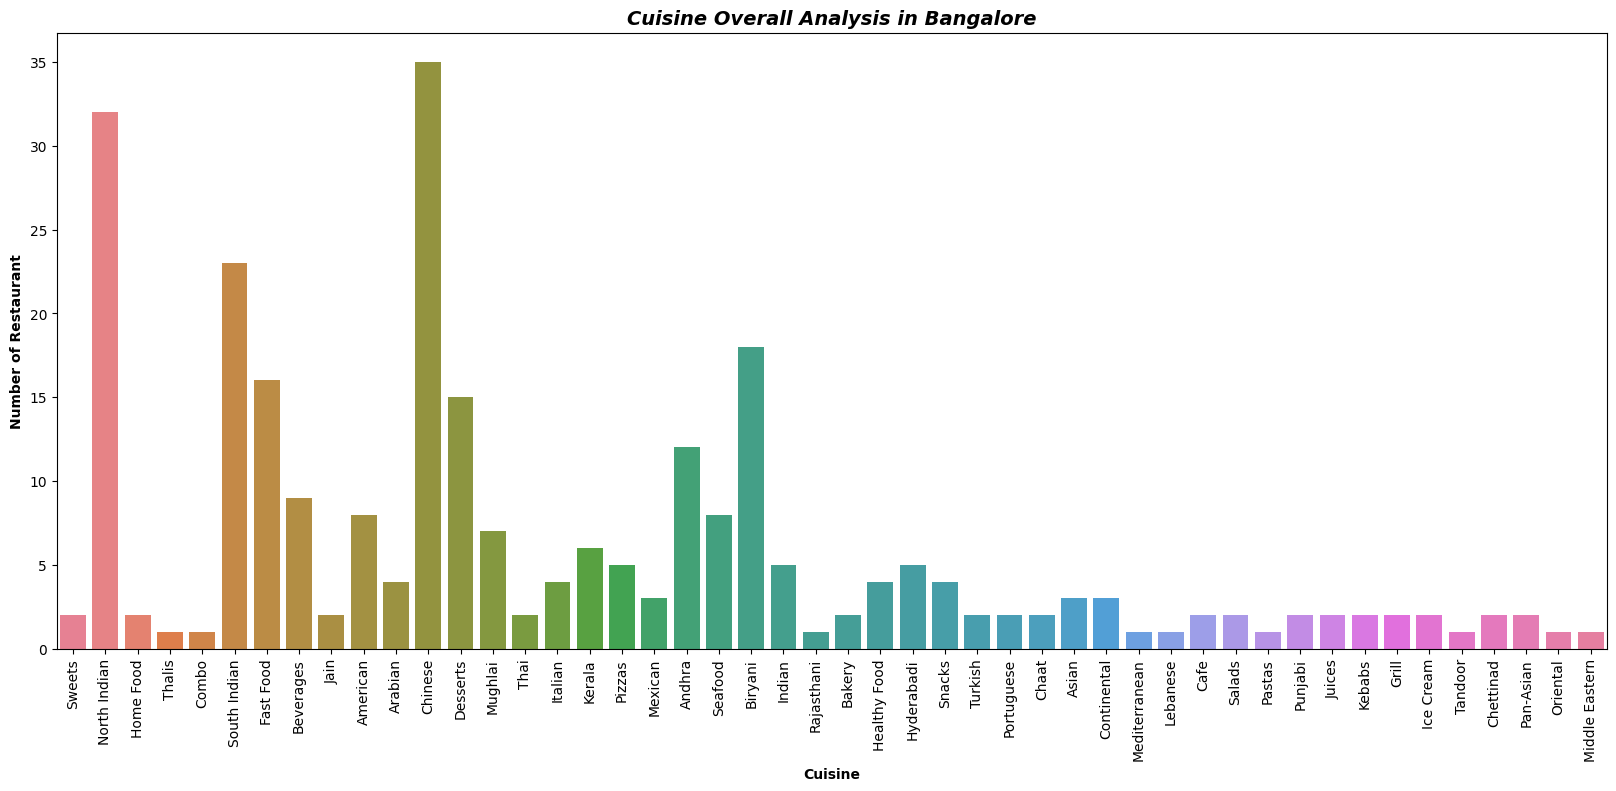

In [51]:
plt.figure(figsize=(20,8))  # 18 & 7 are the size of canva
sns.barplot(x='Cuisine',y='Count',data=df_Cuisine_Analysis,palette='husl')
plt.xticks(rotation=90)
plt.title(
    'Cuisine Overall Analysis in Bangalore',
    fontsize=14,
    fontweight='bold',
    fontstyle='italic'
)
plt.xlabel('Cuisine',fontsize=10,fontweight='bold')
plt.ylabel('Number of Restaurant',fontsize=10,fontweight='bold')
plt.show()

In [52]:
fig=px.pie(
    data_frame=df_Cuisine_Analysis.head(10),
    names=df_Cuisine_Analysis['Cuisine'][0:10],
    values=df_Cuisine_Analysis['Count'][0:10],
    color=df_Cuisine_Analysis['Cuisine'][0:10],
)
fig.update_layout(
    template='plotly_dark',
    title='Distribution of Cuision in Bangalore Restaurants',width=700,height=700
)
fig.show()


In [53]:
freq_BTM={}
for i in Swiggy_BTM["Cuisine"].unique():
  cuisines_List=i.split(",")
  for Cuisine in cuisines_List:
      Cuisine=Cuisine.lstrip()
      if Cuisine in freq_BTM:
         freq_BTM[Cuisine]=freq_BTM[Cuisine]+ 1
      else:
        freq_BTM[Cuisine]=1
print(freq_BTM)
print()
print(len(freq_BTM))

{'Fast Food': 6, 'North Indian': 16, 'Chinese': 18, 'Italian': 1, 'South Indian': 10, 'Desserts': 6, 'Kerala': 4, 'Andhra': 7, 'Beverages': 4, 'Mughlai': 3, 'Seafood': 3, 'Bakery': 1, 'Hyderabadi': 4, 'Indian': 2, 'Biryani': 8, 'Snacks': 1, 'Sweets': 1, 'Chaat': 1, 'Arabian': 2, 'Thai': 1, 'Tandoor': 1, 'Punjabi': 1, 'Healthy Food': 1, 'Chettinad': 1, 'Middle Eastern': 1, 'Grill': 1}

26


In [54]:
Cuisine=freq_BTM.keys()
freq=freq_BTM.values()

dict_BTM={"cuisine":Cuisine,"Count": freq}

df_Cuisine_BTM=pd.DataFrame(dict_BTM)

df_Cuisine_BTM.head()

,cuisine,Count
0,Fast Food,6
1,North Indian,16
2,Chinese,18
3,Italian,1
4,South Indian,10


/tmp/ipykernel_10920/2325799228.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




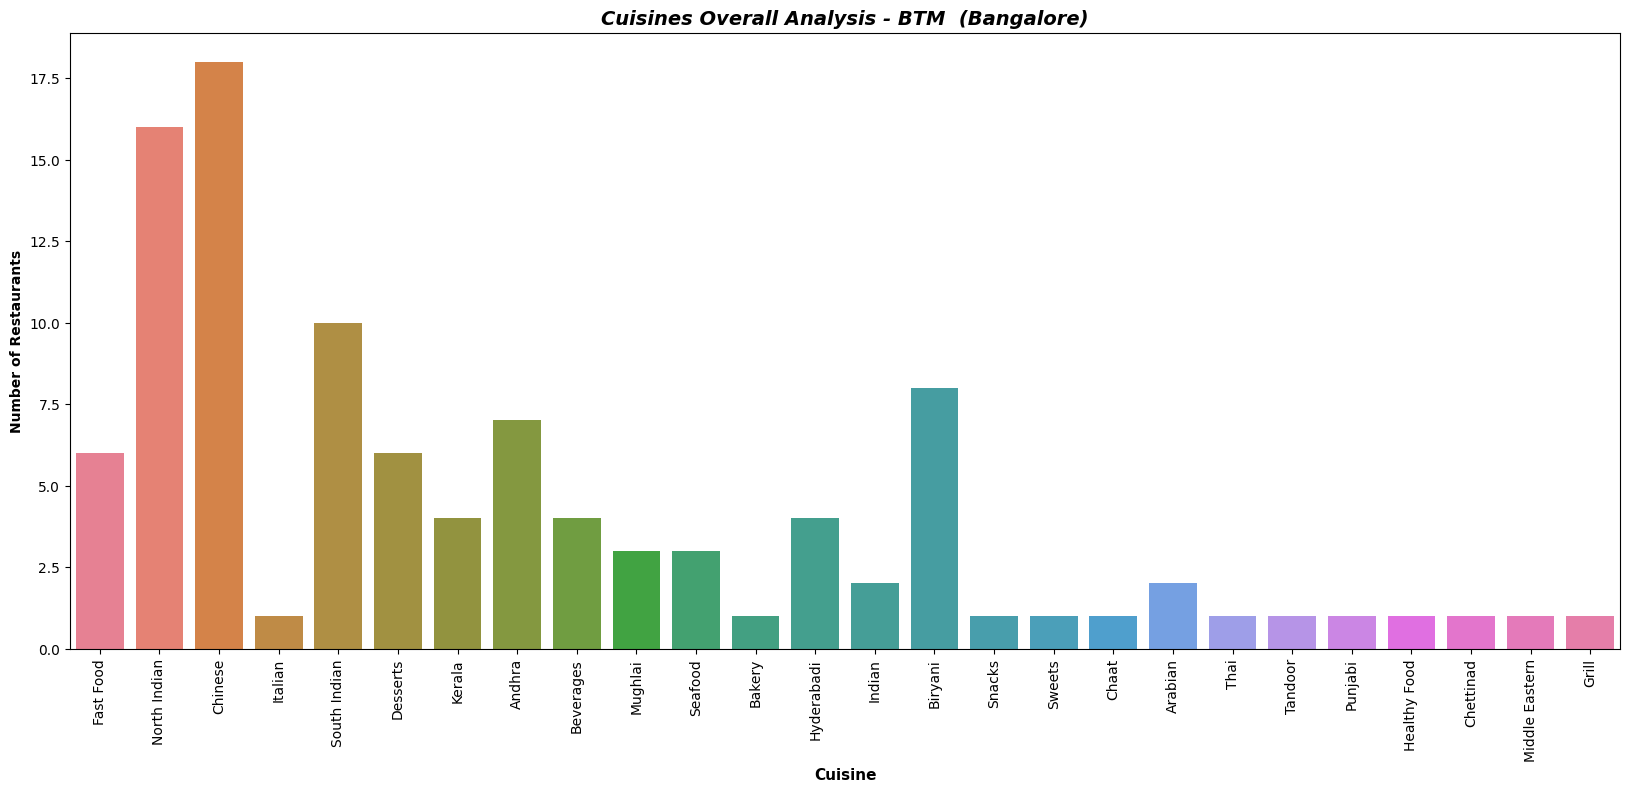

In [55]:
plt.figure(figsize=(20,8))
sns.barplot(x="cuisine",y="Count",data=df_Cuisine_BTM,palette="husl")
plt.xticks(rotation=90)
plt.title(
     "Cuisines Overall Analysis - BTM  (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic"

)
plt.xlabel("Cuisine",fontsize=11, fontweight="bold")
plt.ylabel("Number of Restaurants",fontsize=10, fontweight="bold")
plt.show()

In [56]:
fig=px.pie(
    data_frame=df_Cuisine_BTM,
    names=df_Cuisine_BTM["cuisine"],
    values=df_Cuisine_BTM["Count"],
    title="Distribution of Cuisine in BTM Restaurants",height=700,width=700,
    template="plotly_dark",
    color=df_Cuisine_BTM["cuisine"],
)
fig.update_traces(textposition="inside")
fig.show()

In [57]:
freq_HSR={}
for i in Swiggy_HSR["Cuisine"].unique():
  cuisines_List=i.split(",")
  for Cuisine in cuisines_List:
      Cuisine=Cuisine.lstrip()
      if Cuisine in freq_HSR:
         freq_HSR[Cuisine]=freq_HSR[Cuisine]+ 1
      else:
        freq_HSR[Cuisine]=1
print(freq_HSR)
print()
print(len(freq_HSR))

{'North Indian': 6, 'Home Food': 1, 'Thalis': 1, 'Combo': 1, 'American': 3, 'Arabian': 1, 'Chinese': 4, 'Desserts': 3, 'Fast Food': 1, 'Mughlai': 1, 'South Indian': 4, 'Kerala': 1, 'Indian': 1, 'Rajasthani': 1, 'Jain': 1, 'Biryani': 4, 'Turkish': 1, 'Portuguese': 1, 'Andhra': 1, 'Bakery': 1, 'Juices': 1, 'Kebabs': 1, 'Snacks': 1, 'Chettinad': 1}

24


In [58]:
Cuisine=freq_HSR.keys()
freq=freq_HSR.values()

dict_HSR={"cuisine":Cuisine,"Count": freq}

df_Cuisine_HSR=pd.DataFrame(dict_HSR)

df_Cuisine_HSR.head()

,cuisine,Count
0,North Indian,6
1,Home Food,1
2,Thalis,1
3,Combo,1
4,American,3


/tmp/ipykernel_10920/1621279189.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




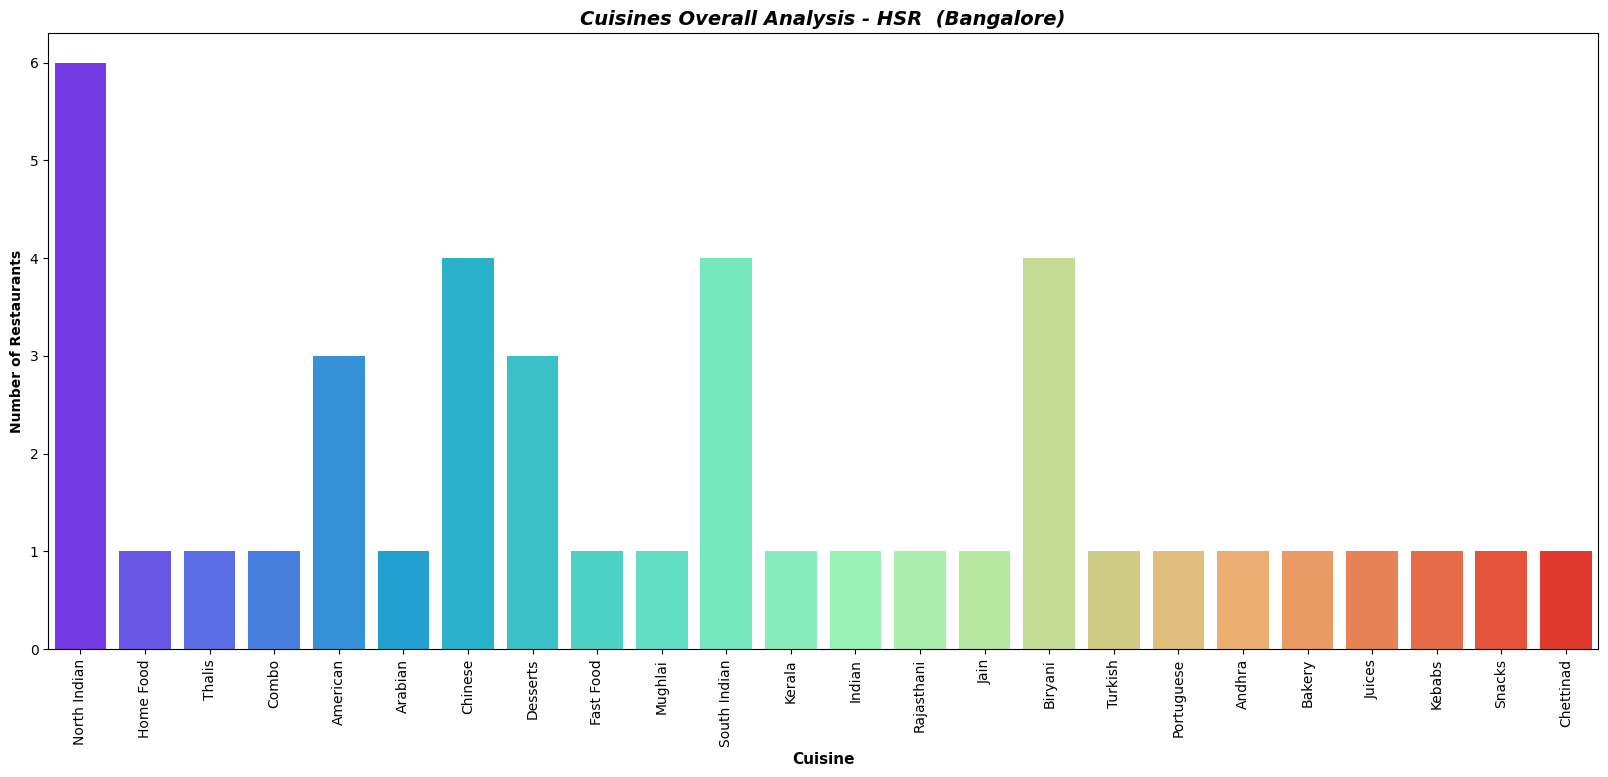

In [59]:
plt.figure(figsize=(20,8))
sns.barplot(x="cuisine",y="Count",data=df_Cuisine_HSR,palette="rainbow")
plt.xticks(rotation=90)
plt.title(
     "Cuisines Overall Analysis - HSR  (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle='oblique',
)
plt.xlabel("Cuisine",fontsize=11, fontweight="bold")
plt.ylabel("Number of Restaurants",fontsize=10, fontweight="bold")
plt.show()

In [60]:
fig=px.pie(
    data_frame=df_Cuisine_HSR,
    names=df_Cuisine_HSR["cuisine"],
    values=df_Cuisine_HSR["Count"],
    title="Distribution of Cuisine in HSR Restaurants",height=700,width=700,
    template="plotly_dark",
    color=df_Cuisine_HSR["cuisine"],
)
fig.update_traces(textposition="inside")
fig.show()

In [61]:
freq_koramangala={}
for i in Swiggy_Koramangala["Cuisine"].unique():
  cuisines_List=i.split(",")
  for Cuisine in cuisines_List:
      Cuisine=Cuisine.lstrip(' ')
      if Cuisine in freq_koramangala:
         freq_koramangala[Cuisine]=freq_koramangala[Cuisine]+ 1
      else:
        freq_koramangala[Cuisine]=1
print(freq_koramangala)
print()
print(len(freq_koramangala))

{'Sweets': 1, 'South Indian': 11, 'North Indian': 14, 'Fast Food': 9, 'Beverages': 5, 'Jain': 1, 'Chinese': 15, 'Thai': 2, 'Pizzas': 5, 'Italian': 4, 'Mexican': 3, 'Desserts': 8, 'Andhra': 5, 'Biryani': 10, 'Seafood': 5, 'Arabian': 1, 'Healthy Food': 3, 'American': 6, 'Snacks': 3, 'Mughlai': 3, 'Asian': 3, 'Continental': 3, 'Mediterranean': 1, 'Lebanese': 1, 'Bakery': 1, 'Cafe': 2, 'Salads': 2, 'Pastas': 1, 'Punjabi': 1, 'Hyderabadi': 1, 'Kerala': 1, 'Turkish': 1, 'Portuguese': 1, 'Grill': 1, 'Home Food': 1, 'Indian': 2, 'Ice Cream': 2, 'Juices': 1, 'Chaat': 1, 'Kebabs': 1, 'Pan-Asian': 2, 'Oriental': 1}

42


In [62]:
Cuisine=freq_koramangala.keys()
freq=freq_koramangala.values()

dict_koramangala={"cuisine":Cuisine,"Count": freq}

df_Cuisine_koramangala=pd.DataFrame(dict_koramangala)

df_Cuisine_koramangala.head()

,cuisine,Count
0,Sweets,1
1,South Indian,11
2,North Indian,14
3,Fast Food,9
4,Beverages,5


/tmp/ipykernel_10920/683021457.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




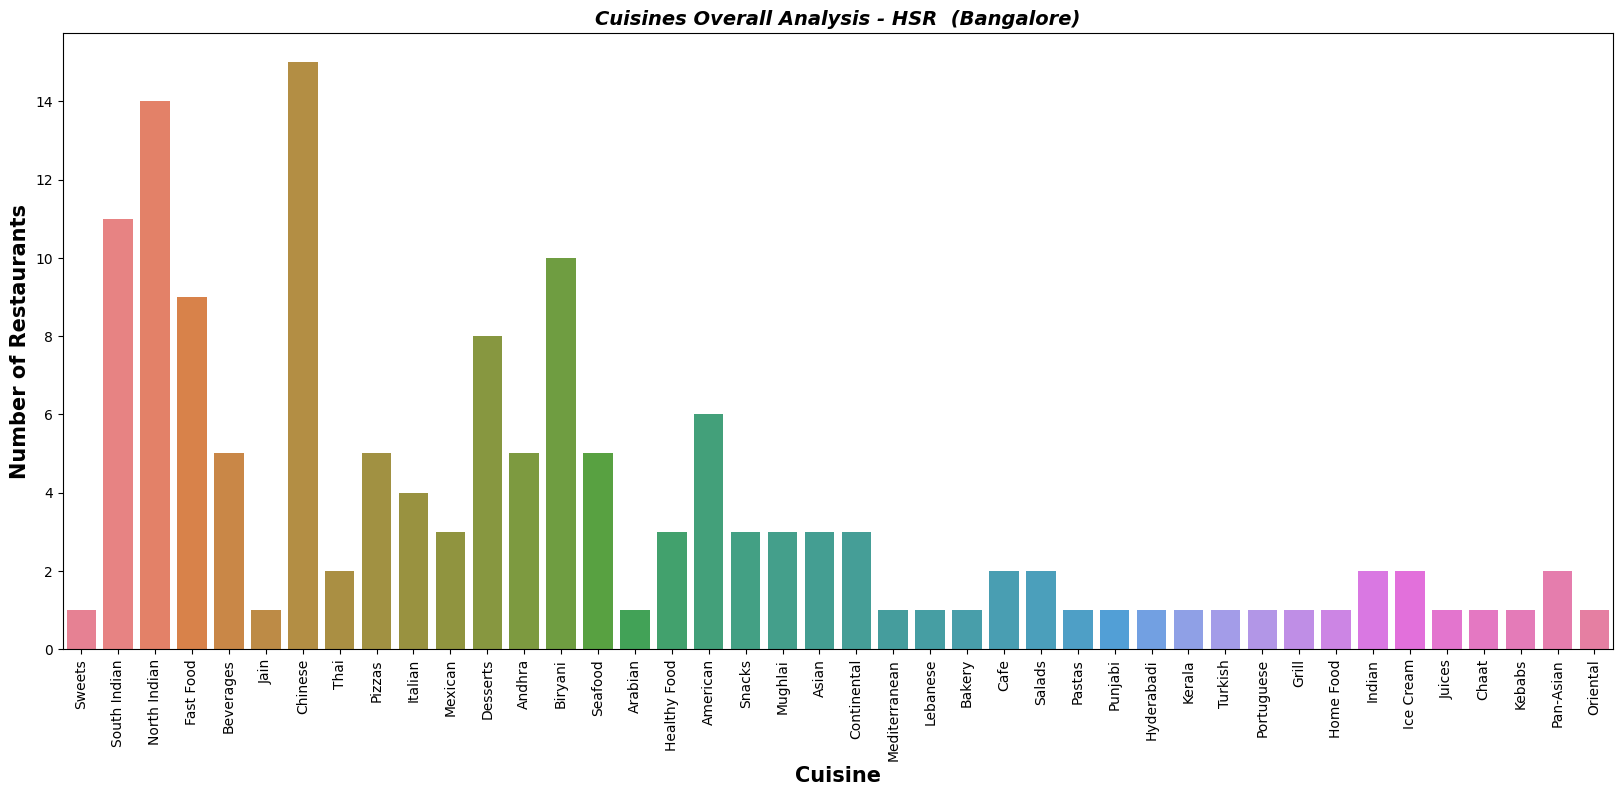

In [63]:
plt.figure(figsize=(20,8))
sns.barplot(x="cuisine",y="Count",data=df_Cuisine_koramangala,palette="husl")
plt.xticks(rotation=90)
plt.title(
     "Cuisines Overall Analysis - HSR  (Bangalore)",
    fontsize=14,
    fontweight="bold",
    fontstyle='oblique',
)
plt.xlabel("Cuisine",fontsize=15, fontweight="bold")
plt.ylabel("Number of Restaurants",fontsize=15, fontweight="bold")
plt.show()

In [64]:
# To save any fig
# plt.savefig("fig_name.png")

In [65]:
fig=px.pie(
    data_frame=df_Cuisine_koramangala,
    names=df_Cuisine_koramangala["cuisine"],
    values=df_Cuisine_koramangala["Count"],
    title="Distribution of Cuisine in Koramangala Restaurants",height=800,width=800,
    template="plotly_dark",
    color=df_Cuisine_koramangala["cuisine"],
)
plt.savefig("Taj.png")
fig.show()

<Figure size 640x480 with 0 Axes>